<a href="https://colab.research.google.com/github/Shinyhunter95/Project-6070/blob/main/Project_6070.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from google.colab import files
uploaded = files.upload()

# Country =	Czechoslovakia
# Station =	Decin
# River =	Elbe
# Area =	51104 km2
# Lat =	50.78
# Lon =	14.22
# Source =	RivDIS
# PointID =	1240
# Area Units =	km2
# Discharge Units =	m3/sec
# Starting Year =	1851
# Ending Year =	1984
# Total Years =	134
# Total Usable Years =	134


Saving elbe.txt to elbe (1).txt


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("elbe.txt", sep="\t")
N = len(df)


# Averages and Standard Deviations (Stripped from the data for easier loading.)
avg = [319.62, 391.22, 520.19, 496.91, 344.51, 258.57, 222.2, 198.86, 191.3, 206.13, 222.32, 274.12]
std_dev = [220.25, 242.21, 265.89, 255.82, 166.29, 170.13, 148.07, 128.76, 150.68, 123.26, 141.57, 188.95]

annual_avg = 303.83
annual_std = 90.5

df_avg = pd.DataFrame(avg, columns=['Avg'])
df_std = pd.DataFrame(std_dev, columns=['Std Dev'])

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]


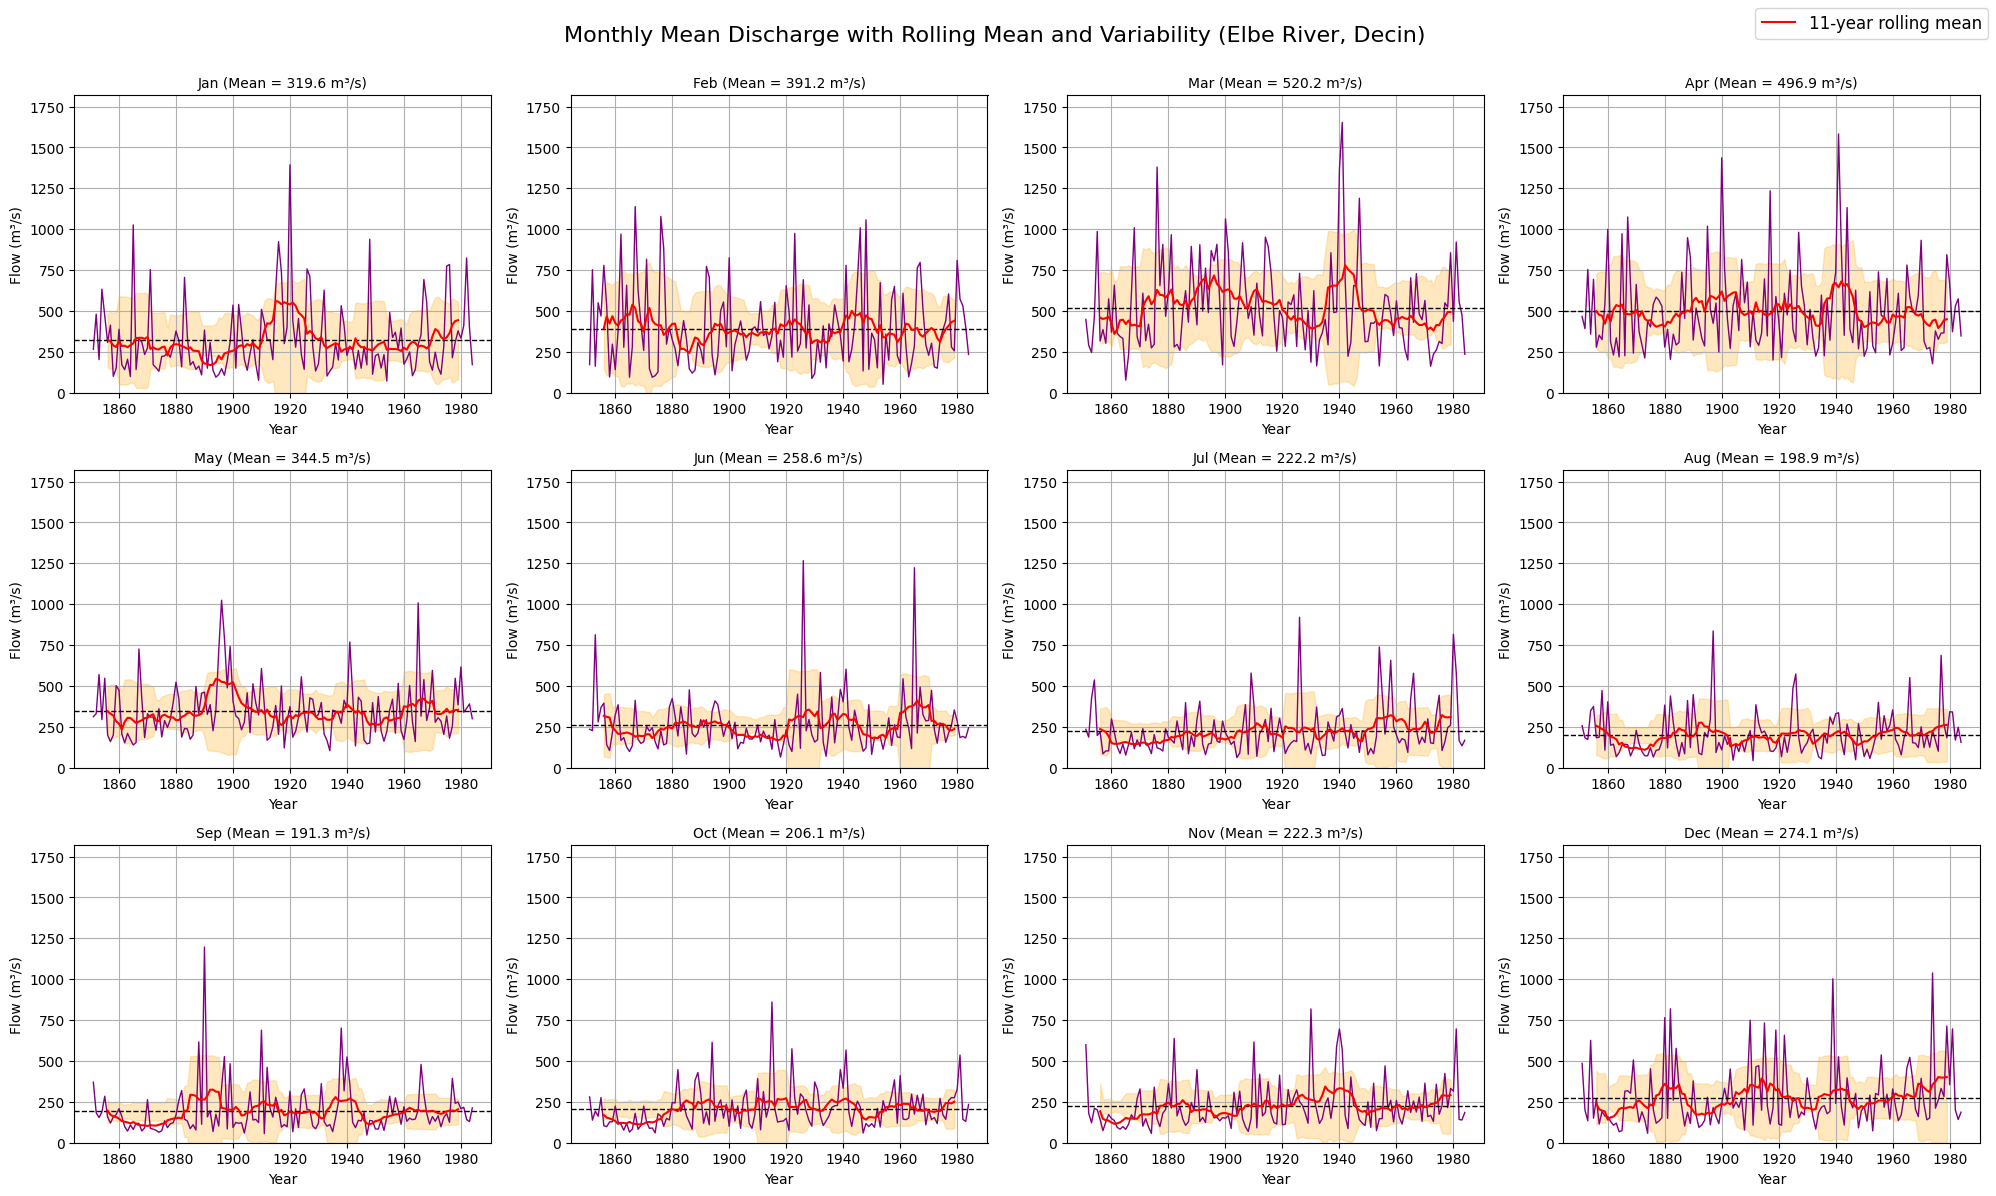

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

window = 11  # rolling window in years

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month]

    # Plot monthly data
    axes[idx].plot(df["Year"], data, color='purple', linewidth=1)

    # Add long-term mean line
    axes[idx].axhline(avg[idx], color='black', linestyle='--', linewidth=1)

    # Compute and plot rolling mean
    rolling_mean = data.rolling(window=window, center=True).mean()
    axes[idx].plot(df["Year"], rolling_mean, color='red', linewidth=1.5, label=f'{window}-year rolling mean')

    # Compute and shade rolling std deviation
    rolling_std = data.rolling(window=window, center=True).std()
    axes[idx].fill_between(
        df["Year"],
        avg[idx] - rolling_std,
        avg[idx] + rolling_std,
        color='orange',
        alpha=0.25
    )

    # Subplot title including mean
    axes[idx].set_title(f"{month} (Mean = {avg[idx]:.1f} m³/s)", fontsize=10)

    # Axis labels
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("Flow (m³/s)")
    axes[idx].grid(True)

    # Uniform y-axis for easier seasonal comparison
    axes[idx].set_ylim(0, max(df[months].max()) * 1.1)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Main figure title
plt.suptitle("Monthly Mean Discharge with Rolling Mean and Variability (Elbe River, Decin)", fontsize=16)

# Figure-level legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=12)

plt.show()

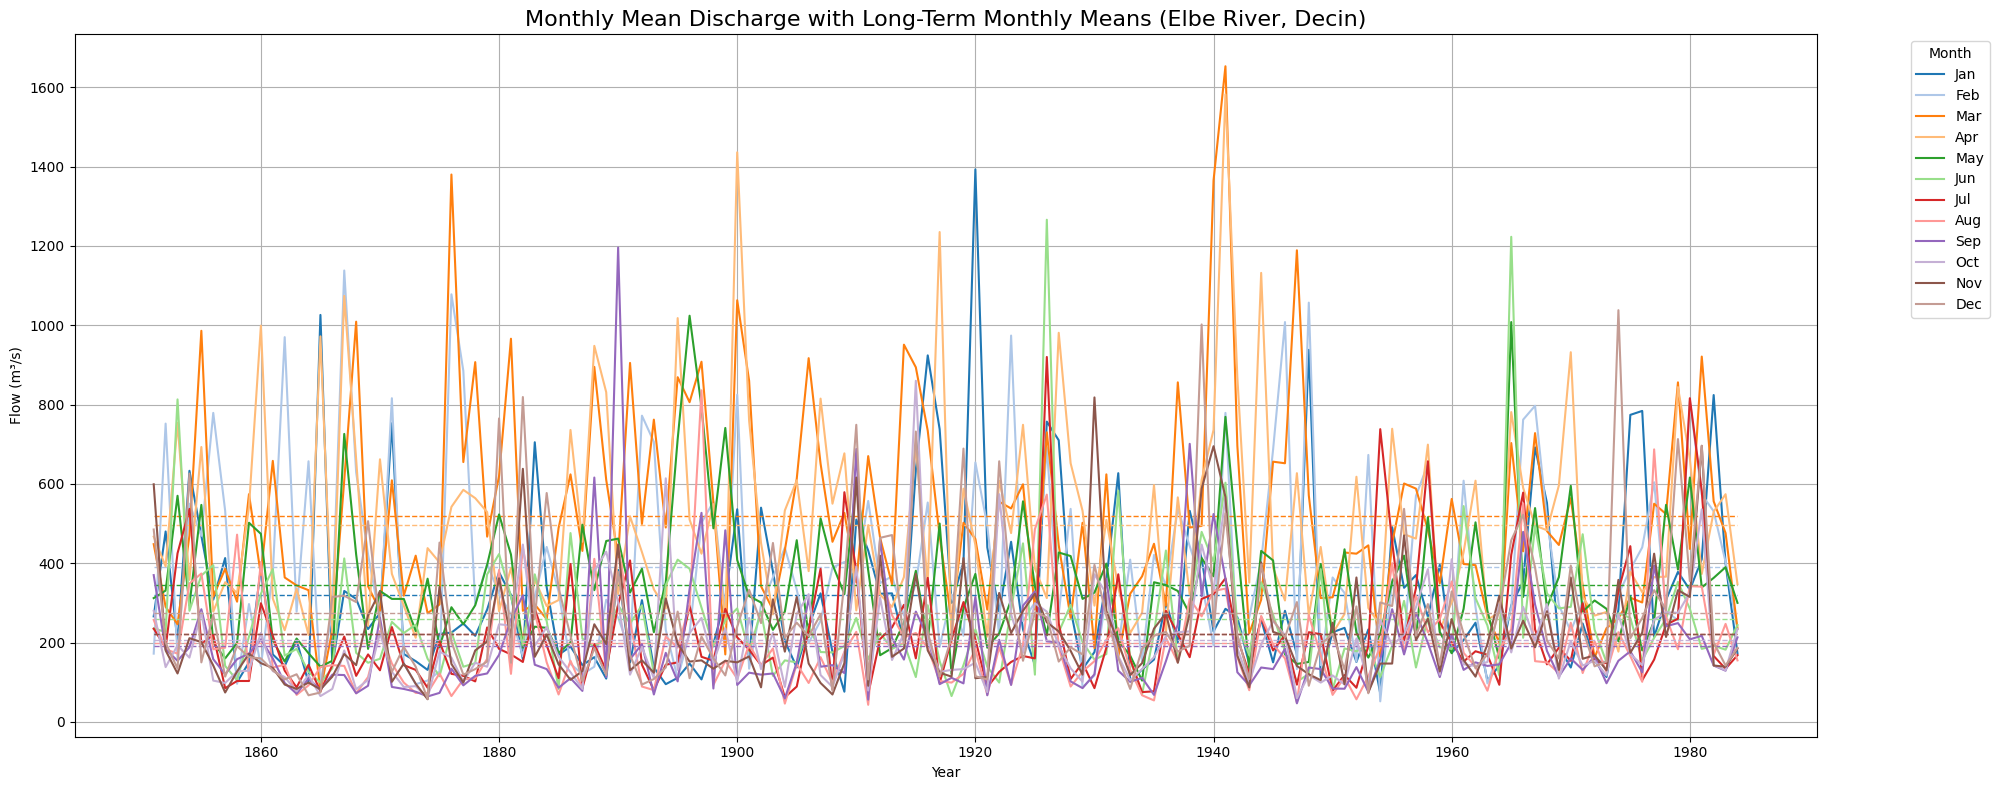

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Color palette with 12 distinct colors
colors = cm.tab20.colors  # plenty for 12 months

plt.figure(figsize=(20, 8))

for idx, month in enumerate(months):
    # Plot monthly discharge
    plt.plot(df["Year"], df[month], color=colors[idx], linewidth=1.5, label=month)

    # Long-term monthly mean as dashed line
    plt.hlines(avg[idx], df["Year"].min(), df["Year"].max(),
               colors=colors[idx], linestyles='--', linewidth=1)

# Titles and labels
plt.title("Monthly Mean Discharge with Long-Term Monthly Means (Elbe River, Decin)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Flow (m³/s)")
plt.grid(True)

# Legend outside plot
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


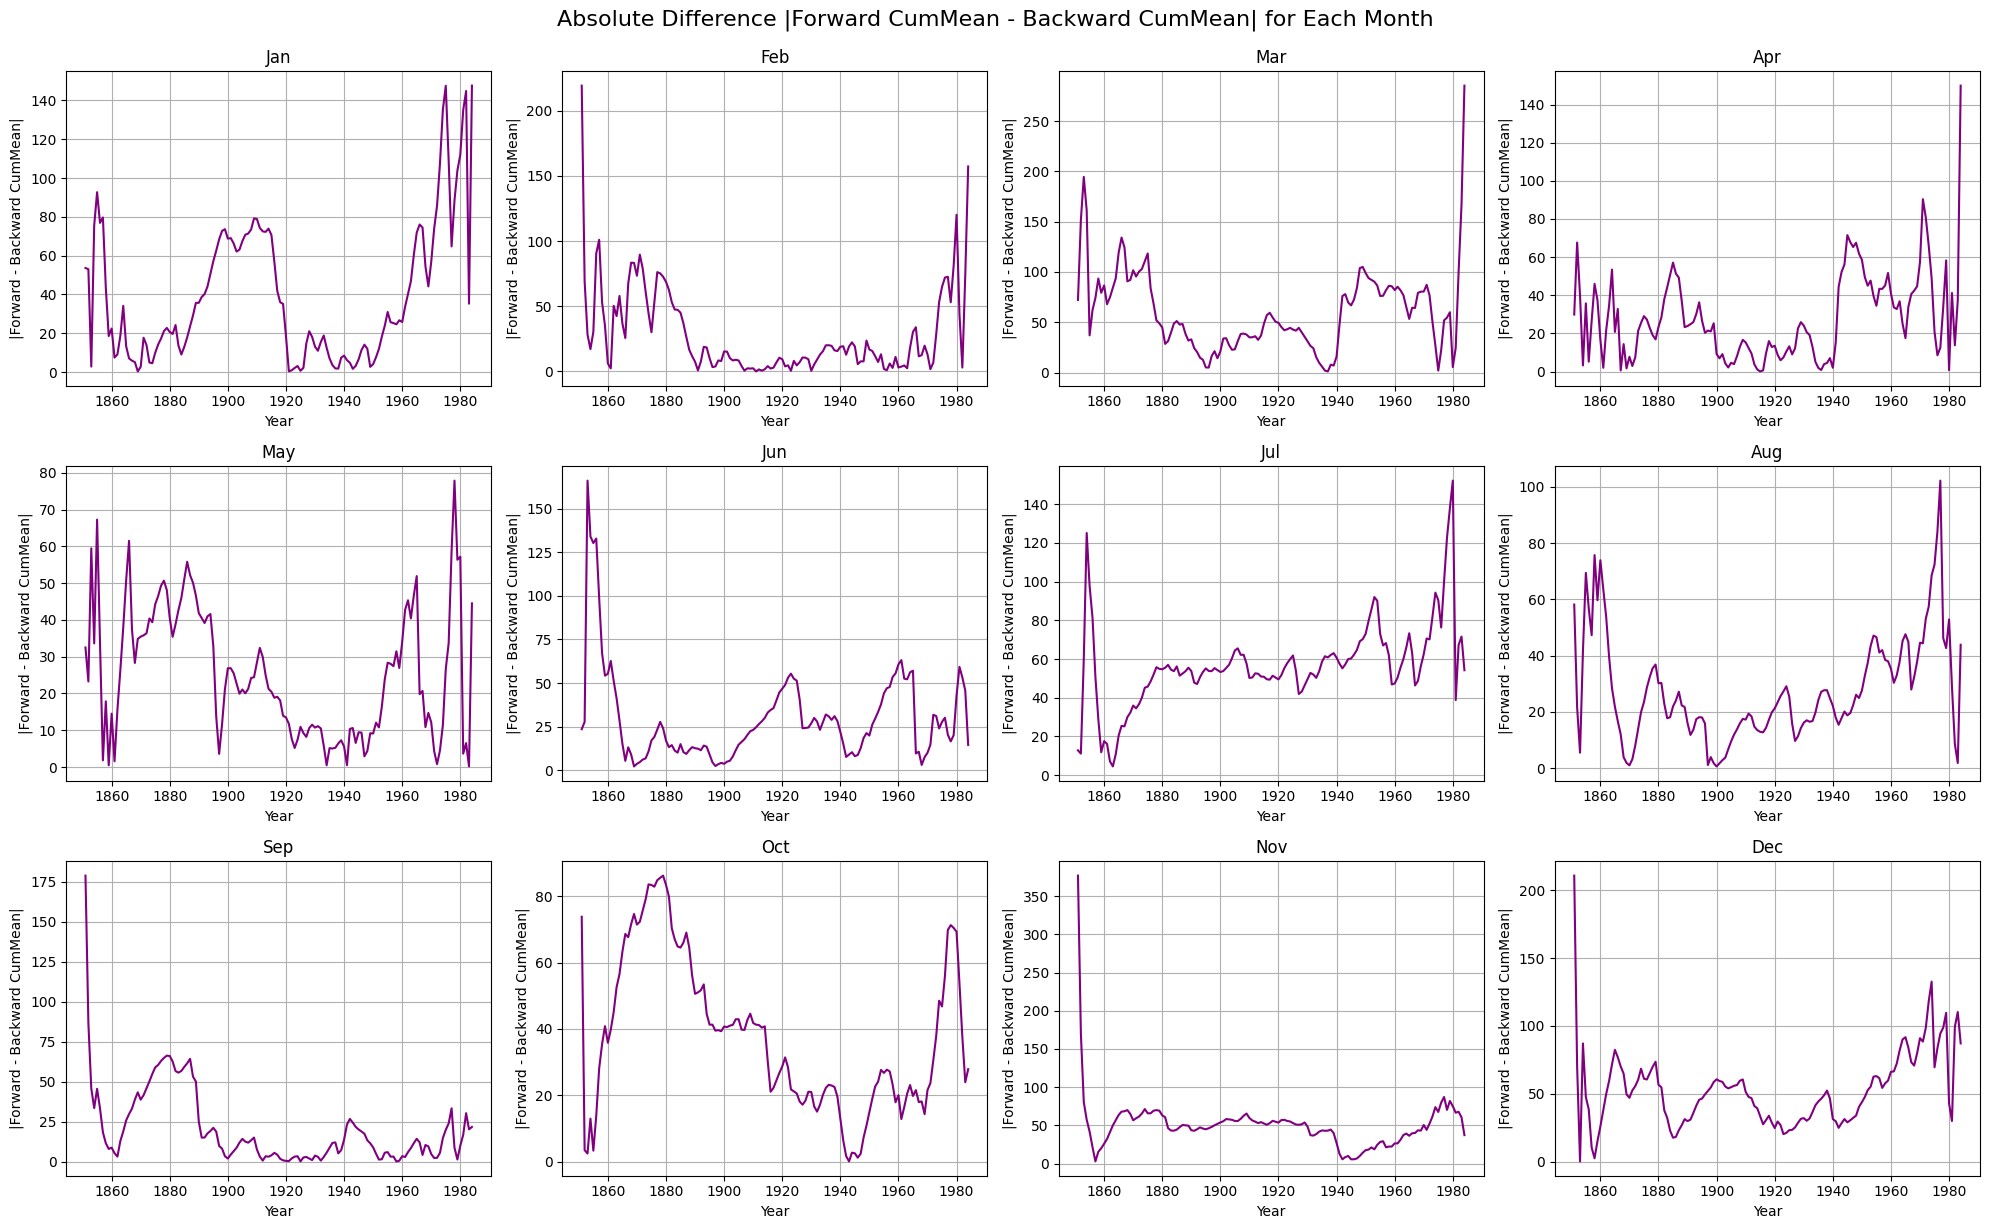

In [ ]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()  # flatten to index easily

for idx, month in enumerate(months):
    data = df[month]

    # Forward cumulative mean
    forward_cummean = data.expanding().mean()

    # Backward cumulative mean
    backward_cummean = data[::-1].expanding().mean()[::-1]

    # Absolute difference
    abs_diff = (forward_cummean - backward_cummean).abs()

    # Plot in corresponding subplot
    axes[idx].plot(df["Year"], abs_diff, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel("|Forward - Backward CumMean|")
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Absolute Difference |Forward CumMean - Backward CumMean| for Each Month", fontsize=16, y=1.02)
plt.show()

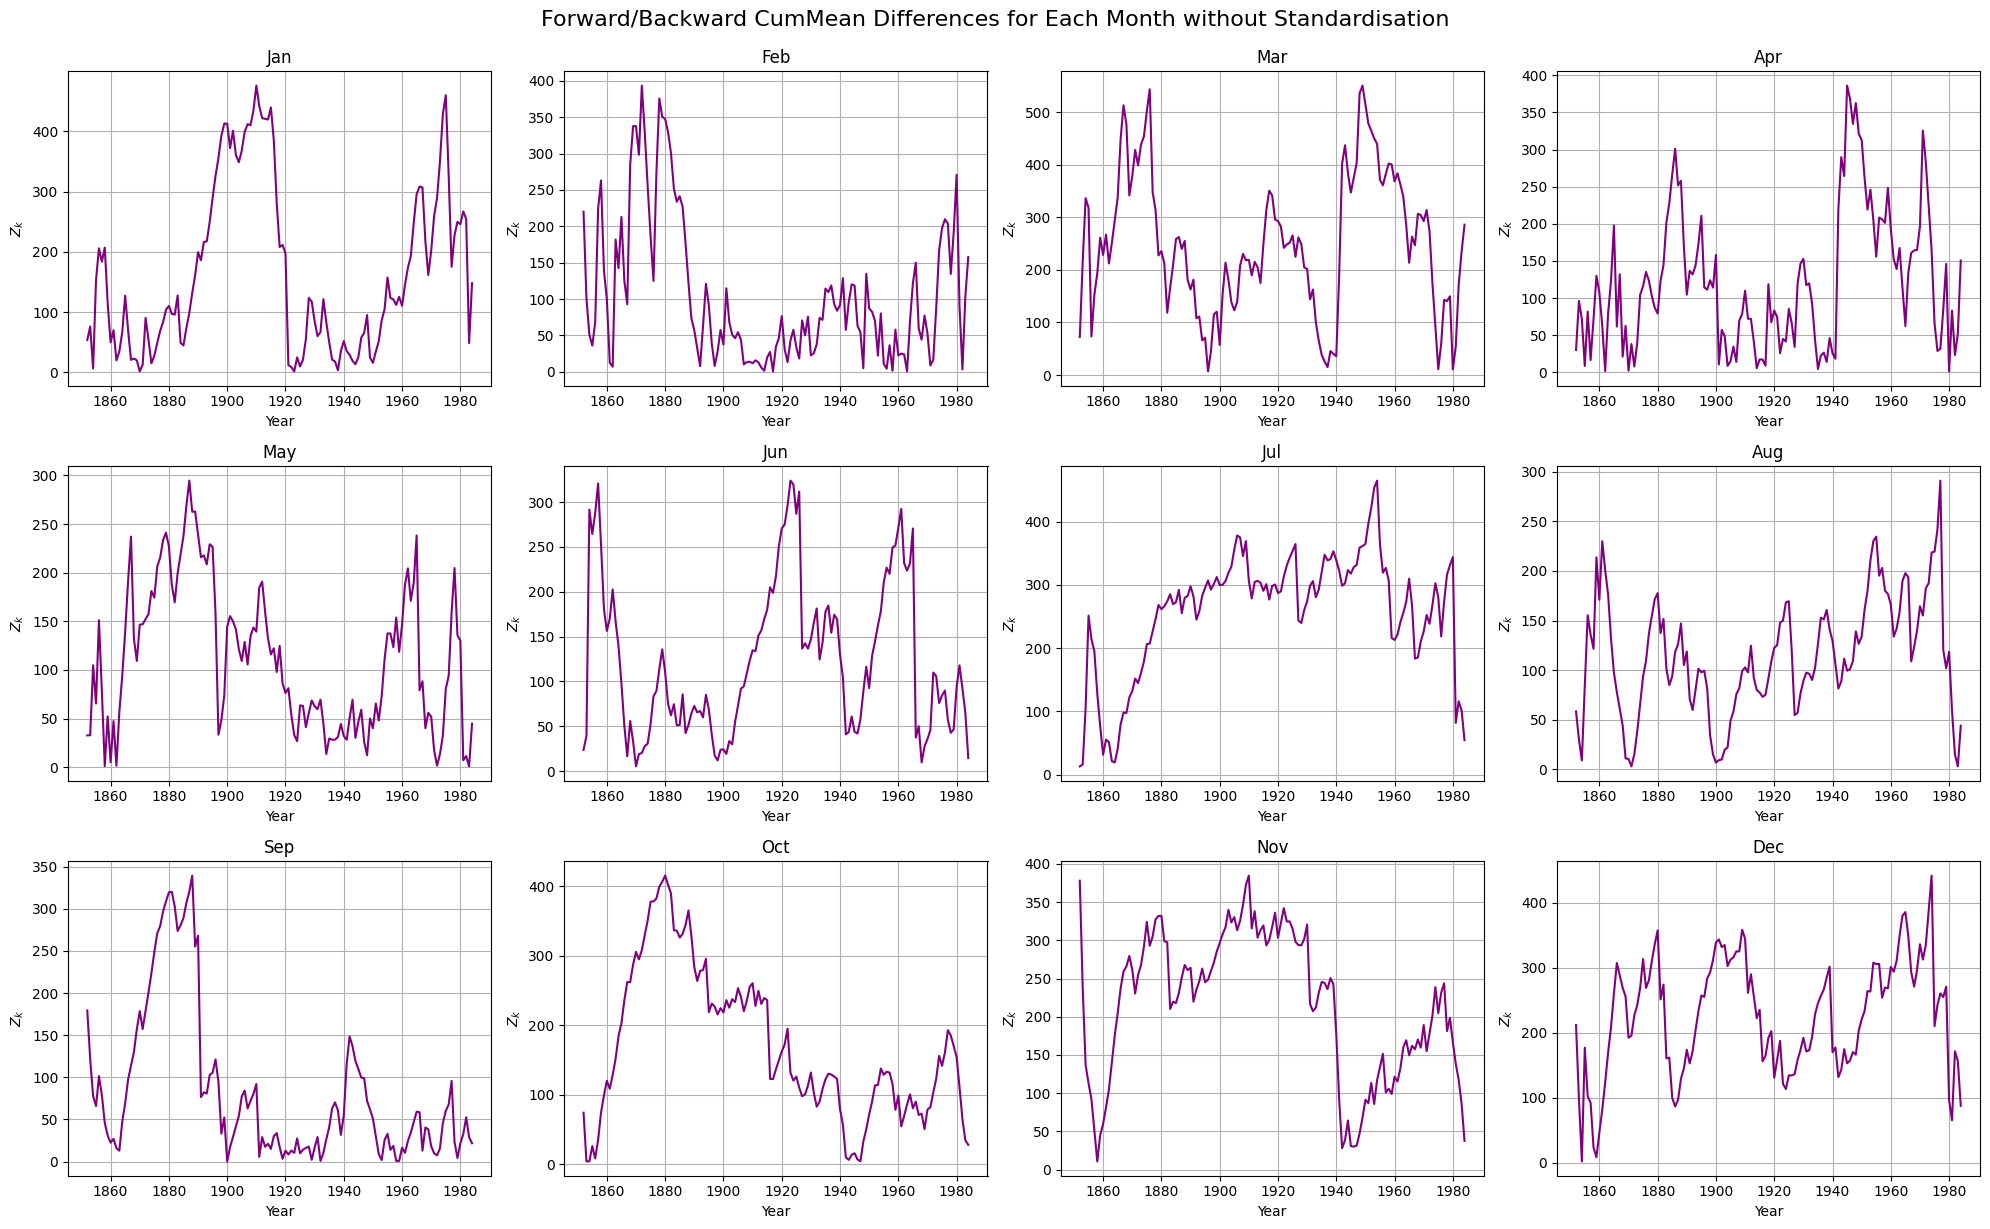

In [ ]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values

    Z = []
    for k in range(1, N):  # from year 1 to N-1
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Simplified standardized statistic
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean)
        Z.append(Zk)

    # Plot Z_k vs Year
    axes[idx].plot(df["Year"][1:], Z, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$Z_k$")
    # axes[idx].axhline(y=1, color='red', linestyle='--', label='Threshold')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Forward/Backward CumMean Differences for Each Month without Standardization", fontsize=16, y=1.02)
plt.show()

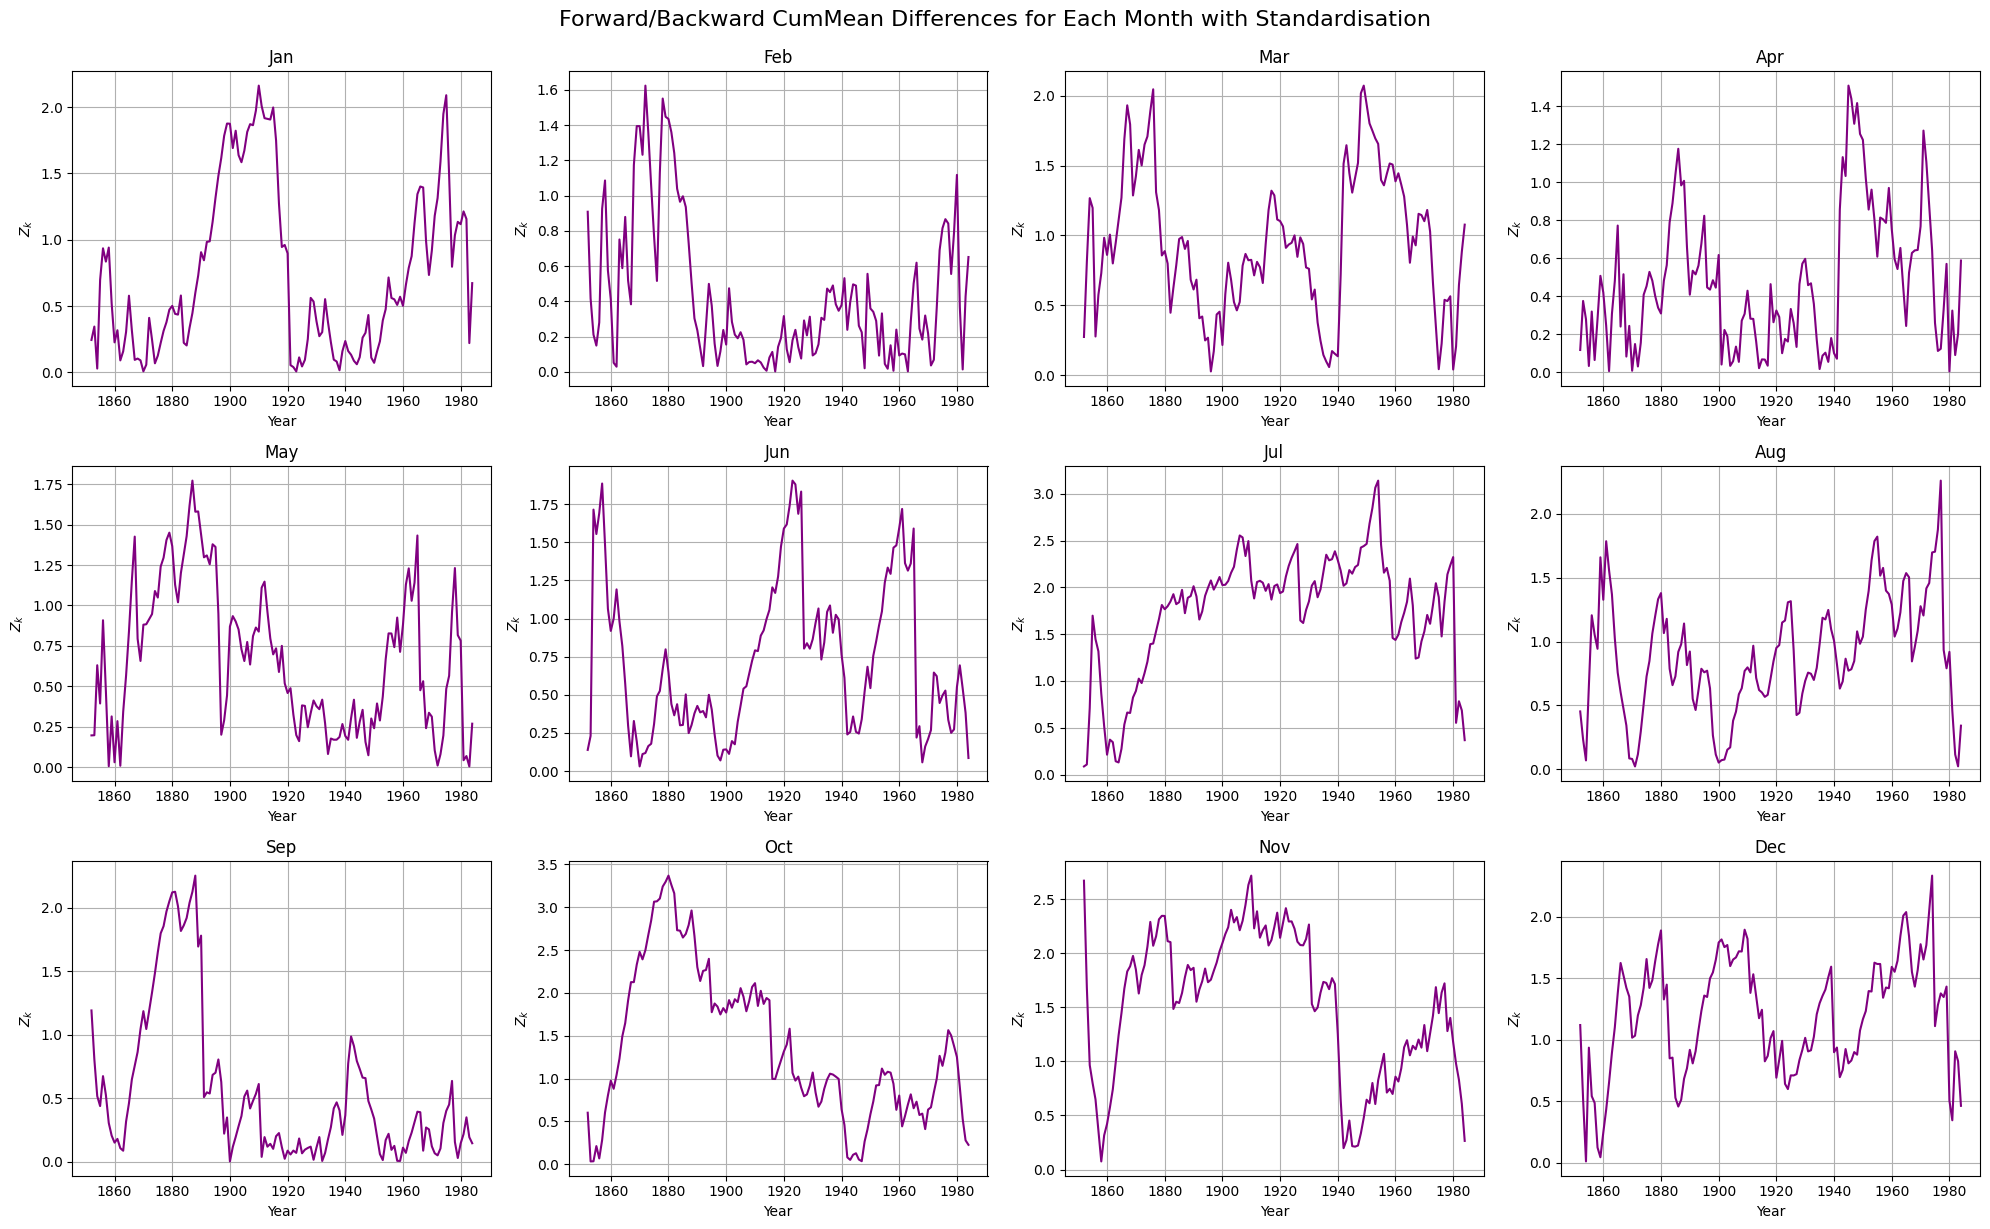

In [ ]:
# 3x4 plot of the 12 Months
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for idx, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[idx]

    Z = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        # Proper standardized Z_k
        Zk = (N / (k * (N - k)))**(-0.5) * abs(forward_mean - backward_mean) / sigma
        Z.append(Zk)

    # Plot Z_k vs Year
    axes[idx].plot(df["Year"][1:], Z, color='purple')
    axes[idx].set_title(month)
    axes[idx].set_xlabel("Year")
    axes[idx].set_ylabel(r"$Z_k$")
    # axes[idx].axhline(y=1, color='red', linestyle='--', label='Threshold')
    axes[idx].grid(True)

plt.tight_layout()
plt.suptitle("Forward/Backward CumMean Differences for Each Month with Standardization", fontsize=16, y=1.02)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata

def pettitt_test(x):
    N = len(x)
    ranks = rankdata(x)  # ranks 1..N
    U = np.array([2*np.sum(ranks[:t]) - t*(N+1) for t in range(1, N)])
    K = np.max(np.abs(U))
    change_point = np.argmax(np.abs(U)) + 1
    p = 2 * np.exp(-6 * K**2 / (N**3 + N**2))
    return change_point, K, p

# Apply month by month
months = df.columns[1:-1]
results = []

for month in months:
    data = df[month].values
    cp, K, p = pettitt_test(data)
    results.append((month, cp, K, p))

results_df = pd.DataFrame(results, columns=['Month','Change_Year_Index','K','p-value'])
results_df['Change_Year'] = results_df['Change_Year_Index'].apply(lambda x: df['Year'].iloc[x])
results_df = results_df[['Month','Change_Year','K','p-value']]
print(results_df)

   Month  Change_Year       K   p-value
0    Jan         1910  1016.0  0.155380
1    Feb         1872   376.0  1.409472
2    Mar         1876   788.0  0.430071
3    Apr         1886   481.0  1.128045
4    May         1887   767.0  0.466276
5    Jun         1961   691.0  0.613419
6    Jul         1936  1146.0  0.077494
7    Aug         1954   929.0  0.236209
8    Sep         1888   985.0  0.181166
9    Oct         1880  1456.0  0.010524
10   Nov         1922  1402.0  0.015420
11   Dec         1900  1179.0  0.064090


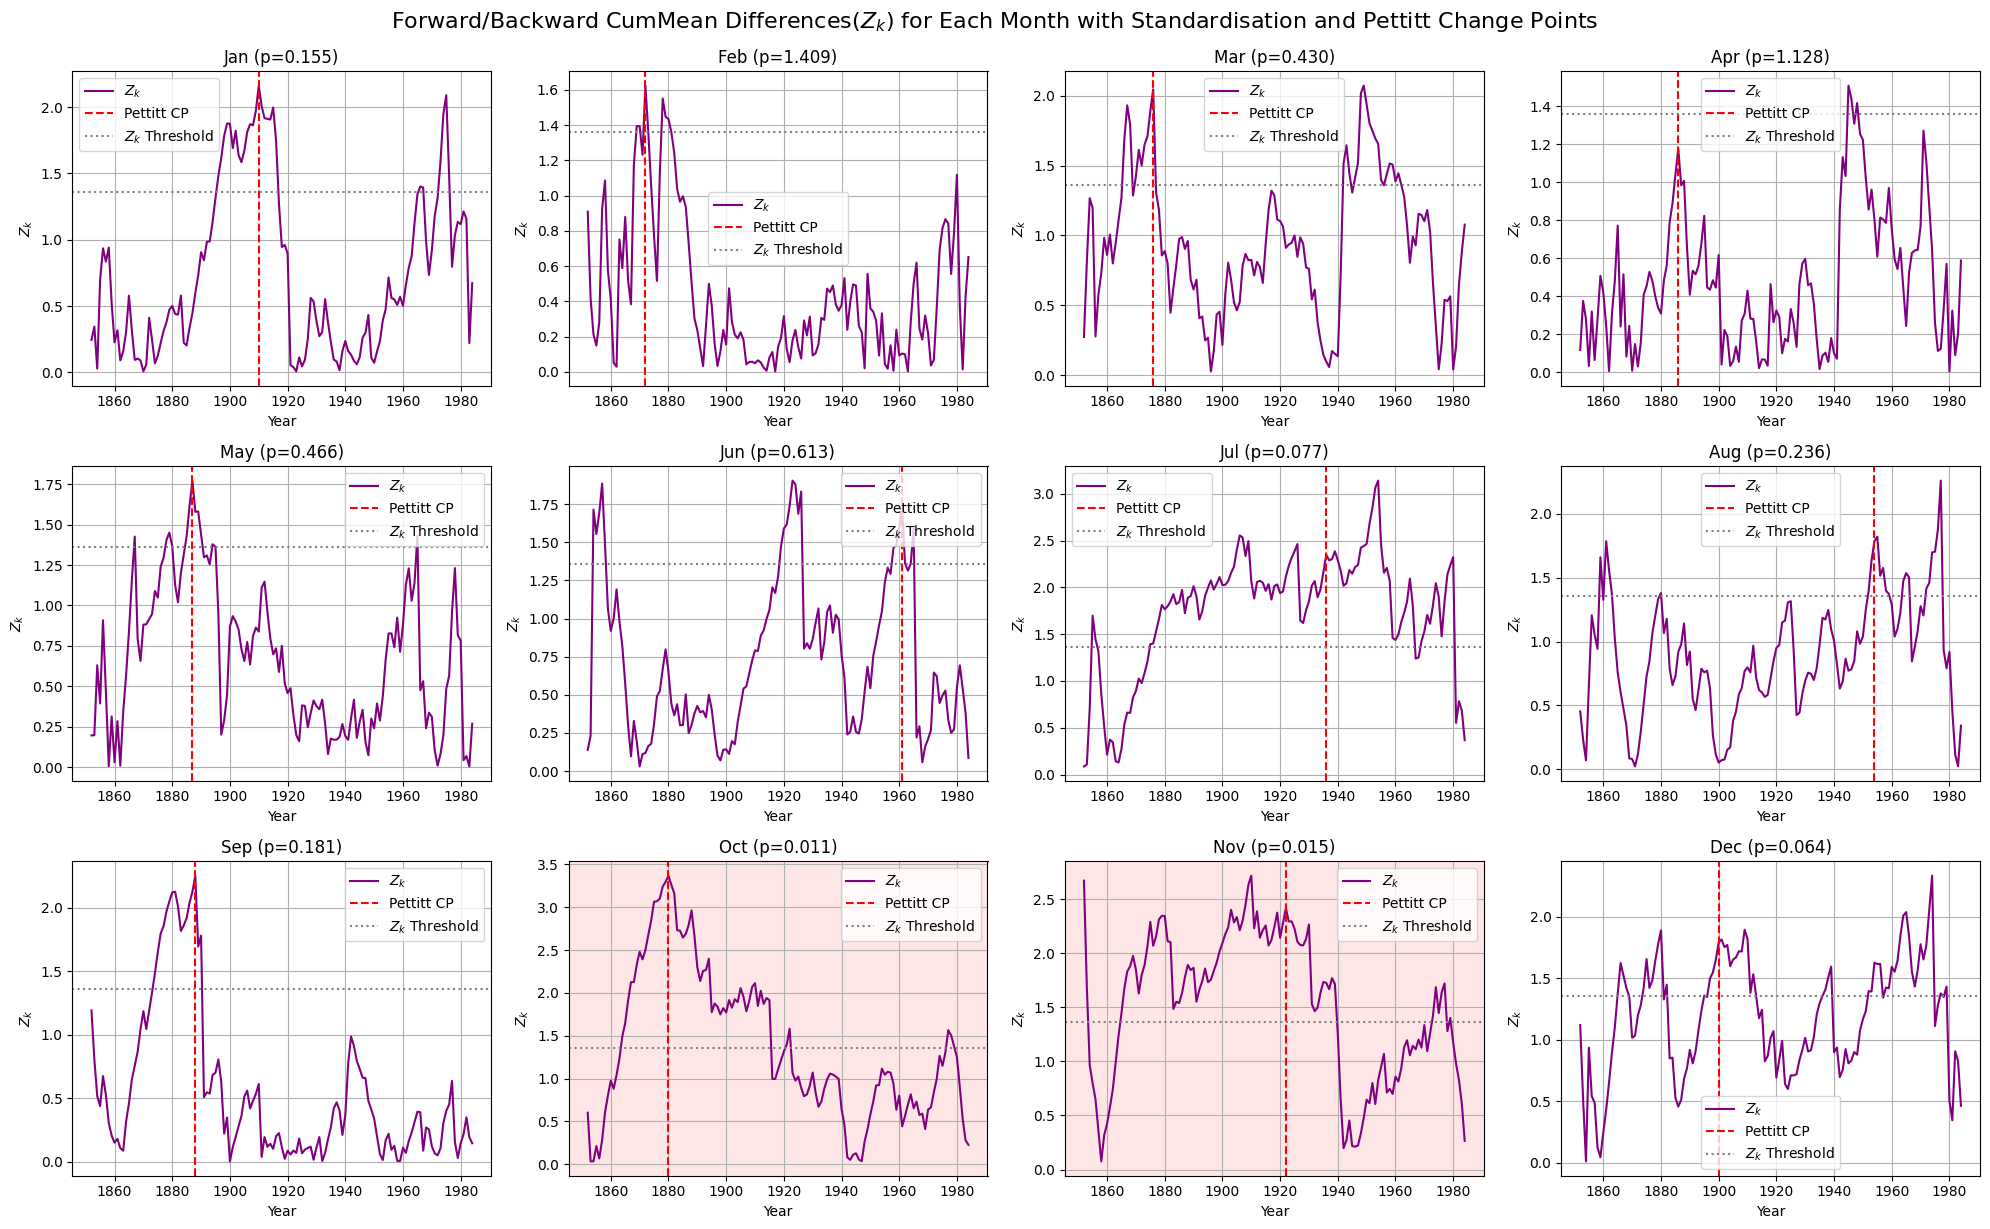

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Threshold for significance
Z_threshold = 1.36
p_threshold = 0.05

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()
N = len(df)

for idx, month in enumerate(months):
    data = df[month].values
    sigma = std_dev[idx]

    # Forward-backward standardized Z_k
    Z = []
    for k in range(1, N):
        forward_mean = np.mean(data[:k])
        backward_mean = np.mean(data[k:])
        Zk = abs(forward_mean - backward_mean) / sigma * np.sqrt(k*(N-k)/N)
        Z.append(Zk)

    axes[idx].plot(df['Year'][1:], Z, color='purple', label=r'$Z_k$')

    # Pettitt change point and p-value
    cp_year = results_df.loc[results_df['Month']==month, 'Change_Year'].values[0]
    p_val = results_df.loc[results_df['Month']==month, 'p-value'].values[0]
    axes[idx].axvline(x=cp_year, color='red', linestyle='--', label='Pettitt CP')

    # Highlight significant months
    if p_val < p_threshold:
        axes[idx].set_facecolor('#ffe6e6')  # light red background

    # Horizontal Z_k threshold
    axes[idx].axhline(y=Z_threshold, color='gray', linestyle=':', label='$Z_k$'' Threshold')

    axes[idx].set_title(f"{month} (p={p_val:.3f})")
    axes[idx].set_xlabel('Year')
    axes[idx].set_ylabel(r'$Z_k$')
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.suptitle("Forward/Backward CumMean Differences(" r"$Z_k$" ") for Each Month with Standardization and Pettitt Change Points", fontsize=16, y=1.02)
plt.show()
